In [25]:
import pandas as pd
from sklearn.datasets import load_wine

# Load the wine dataset into a DataFrame
wine_data = load_wine(as_frame=True)
wine_df = wine_data.frame

print(wine_df.head())

# Display the shape of the DataFrame
print("Shape of the Wine DataFrame:", wine_df.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

wine = load_wine()
X, y = wine.data, wine.target
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
print("Shape:", X.shape)
print("Classes:", list(wine.target_names))
df.head()

Shape: (178, 13)
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [27]:
df.drop(columns='target').describe().T[['mean', 'std', 'min', 'max']]
#Wine Dataset basic details


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


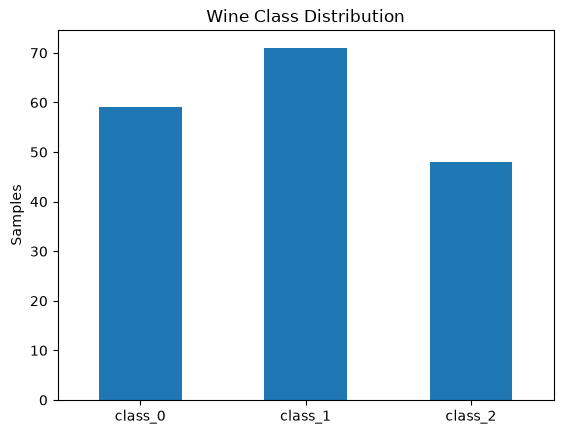

Missing values: 0


In [28]:
# Wine Class distribution
counts = pd.Series(y).map(dict(enumerate(wine.target_names))).value_counts().sort_index()
print(counts)
counts.plot(kind='bar', title='Wine Class Distribution', rot=0)
plt.ylabel('Samples'); plt.show()
print("Missing values:", df.isnull().sum().sum())


#Observations: 

#There are no missing values and there are 3 classes in the dataset. 

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

#We do the 80-20 split of the dataset into training and testing sets, with stratification to maintain class distribution. The training set contains 80% of the data, while the testing set contains 20%.



Train: (142, 13)  Test: (36, 13)


STEP 2  Implement K-Nearest Neighbhors:


In [30]:
k_values = [1, 5, 11, 15, 21]
knn_acc = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    knn_acc.append(acc)

knn_results = pd.DataFrame({'k': k_values, 'accuracy': knn_acc})
knn_results

,k,accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


Step 3 Implement Radius Neighbor:

In [31]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_acc, no_neighbors = [], []
for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    acc = accuracy_score(y_test, rnn.predict(X_test))
    rnn_acc.append(acc)
    counts_in_radius = [len(n) for n in rnn.radius_neighbors(X_test, return_distance=False)]
    no_neighbors.append(sum(c == 0 for c in counts_in_radius))

rnn_results = pd.DataFrame({'radius': radius_values, 'accuracy': rnn_acc,
                            'test points with no neighbors': no_neighbors})
rnn_results


#TestPoint with no neighbors: This column indicates the number of test points that did not have any neighbors within the specified radius. A higher number of test points with no neighbors can lead to lower accuracy,so it's important to consider this metric when evaluating the performance of the Radius Neighbors Classifier.

,radius,accuracy,test points with no neighbors
0,350,0.722222,0
1,400,0.694444,0
2,450,0.694444,0
3,500,0.694444,0
4,550,0.666667,0
5,600,0.666667,0


Step 4: Visualise

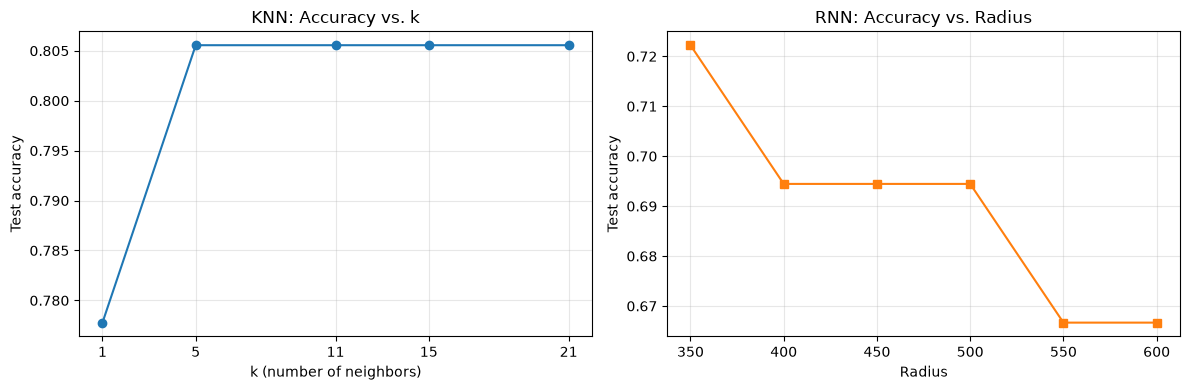

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_values, knn_acc, marker='o')
ax[0].set_title('KNN: Accuracy vs. k')
ax[0].set_xlabel('k (number of neighbors)'); ax[0].set_ylabel('Test accuracy')
ax[0].set_xticks(k_values); ax[0].grid(alpha=0.3)

ax[1].plot(radius_values, rnn_acc, marker='s', color='tab:orange')
ax[1].set_title('RNN: Accuracy vs. Radius')
ax[1].set_xlabel('Radius'); ax[1].set_ylabel('Test accuracy')
ax[1].set_xticks(radius_values); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [33]:
print(f"Best KNN: k={k_values[int(np.argmax(knn_acc))]}, accuracy={max(knn_acc):.4f}")
print(f"Best RNN: radius={radius_values[int(np.argmax(rnn_acc))]}, accuracy={max(rnn_acc):.4f}")
print(f"Mean KNN accuracy: {np.mean(knn_acc):.4f}")
print(f"Mean RNN accuracy: {np.mean(rnn_acc):.4f}")

Best KNN: k=5, accuracy=0.8056
Best RNN: radius=350, accuracy=0.7222
Mean KNN accuracy: 0.8000
Mean RNN accuracy: 0.6898


# Comparison and Discussion

**Results (random_state=42, stratified 80/20 split, 36 test samples):**

| Model | Parameter values | Accuracy range | Best |
|---|---|---|---|
| KNN | k = 1, 5, 11, 15, 21 | 77.8% – 80.6% | 80.6% (k = 5, 11, 15, 21) |
| RNN | radius = 350 – 600 | 66.7% – 72.2% | 72.2% (radius = 350) |

**Observations**

1. **KNN outperformed RNN at every setting tested.** Its mean accuracy was about 80.0% versus about 69.0% for RNN.
2. **KNN trends.** k = 1 was slightly worse (77.8%) because a single neighbor makes the prediction sensitive to noise. Accuracy rose at k = 5 and then stayed flat at 80.6%, so the model is stable across a wide range of k. Each test sample is worth about 2.8 percentage points, so the differences among KNN values amount to only one test sample.
3. **RNN trends.** Accuracy *decreased* as the radius grew, from 72.2% at 350 to 66.7% at 600. With a large radius, each prediction takes a majority vote over a large share of the training set (including points from other classes), so the model drifts toward predicting the majority class. A smaller radius keeps the vote more local.
4. **Why the accuracy is modest overall.** The features are unscaled, so `proline` (range about 278–1680) dominates the Euclidean distance and most other features barely matter. Both models are therefore effectively classifying on proline alone. Standardizing the features typically pushes accuracy on this dataset above 95%. The radii 350–600 only make sense in the raw feature space, which is also why every test point had at least one neighbor and `outlier_label` was never needed.
5. **Caveat.** With only 36 test samples, a single split is a noisy estimate. Cross-validation would give a more reliable comparison.

**When to prefer each method**

- **KNN** is the better default when the data density is fairly uniform or unknown, or when you want a predictable number of neighbors for every query. It always has neighbors to vote on, and in this experiment it was more accurate and much less sensitive to its hyperparameter.
- **RNN** is preferable when density varies across the feature space and you want the neighborhood to adapt: in dense regions it uses many neighbors, and in sparse regions few or none. That lets it flag outliers (query points with no neighbors within the radius), and it suits problems where "similar" has a fixed physical meaning, such as a distance threshold in geospatial or sensor data. Its drawbacks are that the radius must be chosen relative to the feature scale (making scaling essential), and that a poorly chosen radius can leave queries with no neighbors or with far too many, as seen at large radii here.